# Finility Analysis Notebook
This notebook performs EDA, correlations, and regression on merged sentiment and market data.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/merged_sentiment_market.csv", parse_dates=["Date"]).set_index("Date")

df.head()

,return,daily_sentiment,vix
Date,,,
2017-12-18,0.005363,-0.175000,9.53
2017-12-19,-0.003230,-0.650000,10.03
2017-12-20,-0.000828,-0.050000,9.72
2017-12-21,0.001986,0.050000,9.62
2017-12-22,-0.000458,0.304348,9.90


## Summary Statistics

In [4]:
df.describe()

,return,daily_sentiment,vix
count,647.000000,647.000000,647.000000
mean,0.000409,0.036451,19.411963
std,0.015247,0.159011,10.542159
min,-0.119841,-1.000000,9.150000
25%,-0.003848,-0.063494,13.160000
50%,0.000911,0.044776,15.800000
75%,0.006695,0.137459,20.554999
max,0.093828,1.000000,82.690002


## Correlation Matrix

In [5]:
df[['return','daily_sentiment','vix']].corr()

,return,daily_sentiment,vix
return,1.000000,0.092441,-0.150783
daily_sentiment,0.092441,1.000000,-0.305669
vix,-0.150783,-0.305669,1.000000


## Time Series Plots

<Axes: title={'center': 'Daily Sentiment'}, xlabel='Date'>

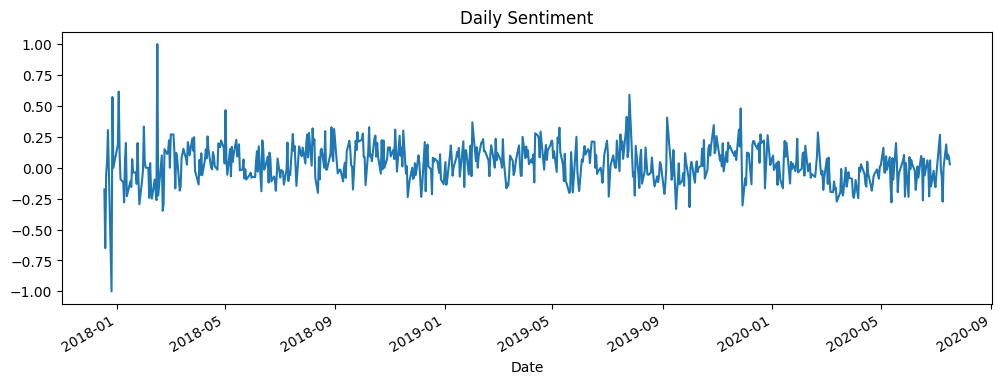

In [6]:
df['daily_sentiment'].plot(figsize=(12,4), title='Daily Sentiment')

<Axes: title={'center': 'S&P 500 Returns'}, xlabel='Date'>

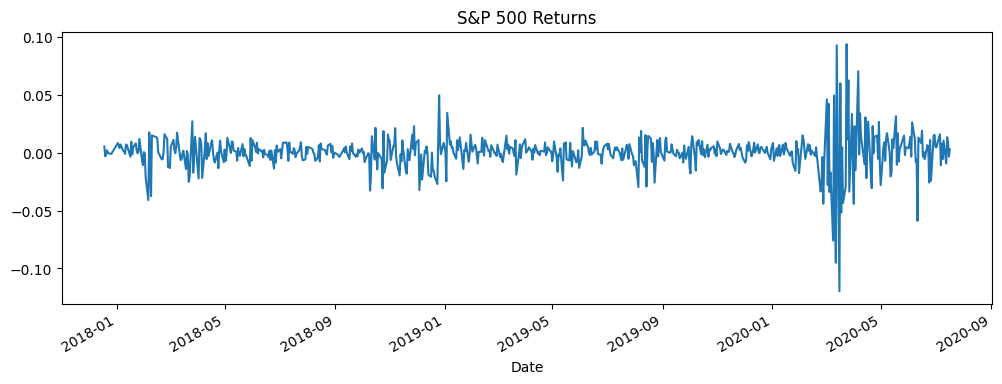

In [7]:
df['return'].plot(figsize=(12,4), title='S&P 500 Returns')

<Axes: title={'center': 'VIX Index'}, xlabel='Date'>

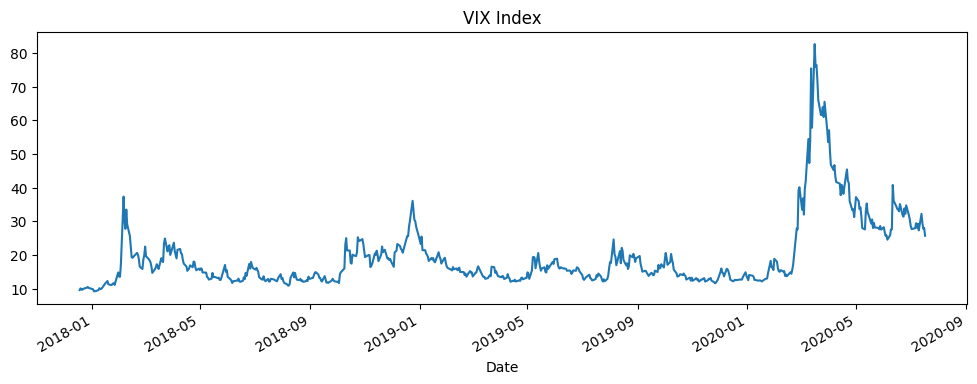

In [8]:
df['vix'].plot(figsize=(12,4), title='VIX Index')

## Add Lag Features

In [9]:
df['sentiment_lag1'] = df['daily_sentiment'].shift(1)
df = df.dropna()
df.head()

,return,daily_sentiment,vix,sentiment_lag1
Date,,,,
2017-12-19,-0.003230,-0.650000,10.03,-0.175000
2017-12-20,-0.000828,-0.050000,9.72,-0.650000
2017-12-21,0.001986,0.050000,9.62,-0.050000
2017-12-22,-0.000458,0.304348,9.90,0.050000
2017-12-26,-0.001058,-1.000000,10.25,0.304348


## Regression Model

In [10]:
import statsmodels.api as sm

X = df[['daily_sentiment','sentiment_lag1','vix']]
y = df['return']
X = sm.add_constant(X)
model = sm.OLS(y,X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 return   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     6.014
Date:                Wed, 19 Nov 2025   Prob (F-statistic):           0.000482
Time:                        15:55:42   Log-Likelihood:                 1794.8
No. Observations:                 646   AIC:                            -3582.
Df Residuals:                     642   BIC:                            -3564.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0045      0.001      3.217      0.001       0.002       0.007
daily_sentiment     0.0053      0.004      1.357      0.175      -0.002       0.013
sentiment_lag1     -0.0048      0.004     -1.227      0.220      -0.013       0.003
vix                -0.0002   6.14e-05     -3.493      0.001      -0.000   -9.39e-05
==============================================================================
Omnibus:                      180.437   Durbin-Watson:                   2.543
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5887.085
Skew:                           0.531   Prob(JB):                         0.00
Kurtosis:                      17.751   Cond. No.                         152.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

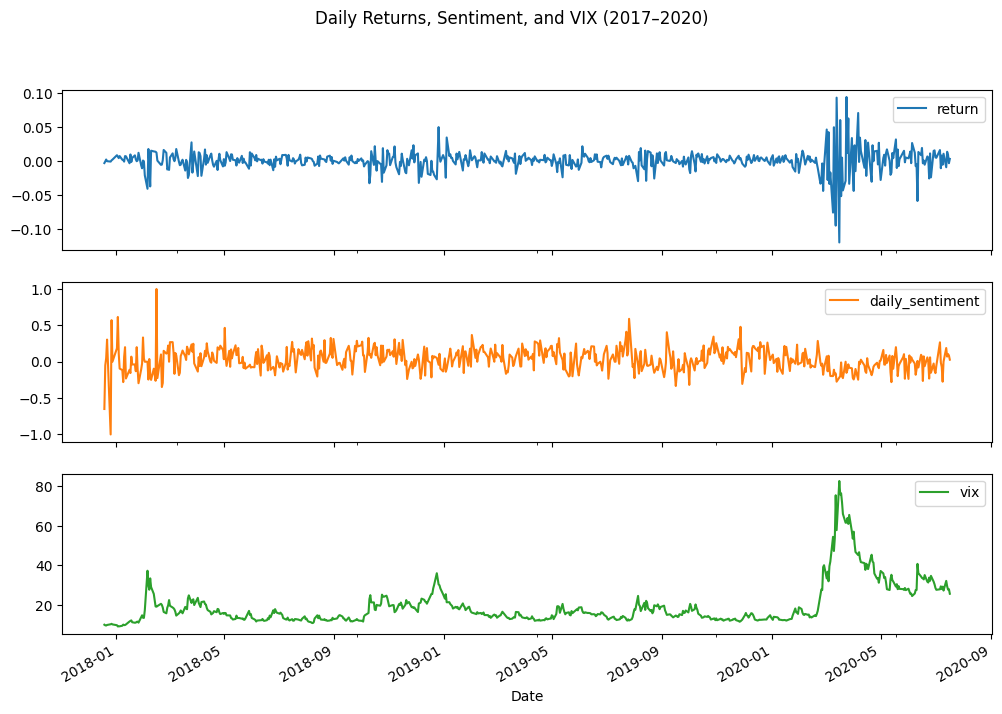

In [11]:
df[['return','daily_sentiment','vix']].plot(subplots=True, figsize=(12,8))
plt.suptitle("Daily Returns, Sentiment, and VIX (2017–2020)")
plt.show()


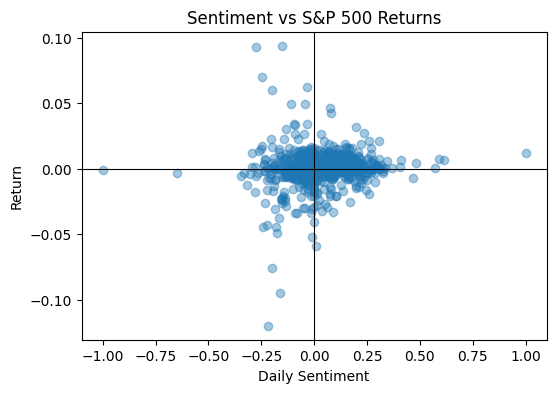

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(df['daily_sentiment'], df['return'], alpha=0.4)
plt.xlabel("Daily Sentiment")
plt.ylabel("Return")
plt.title("Sentiment vs S&P 500 Returns")
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()


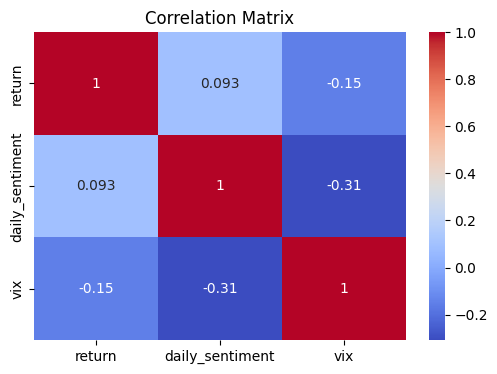

In [13]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(df[['return','daily_sentiment','vix']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


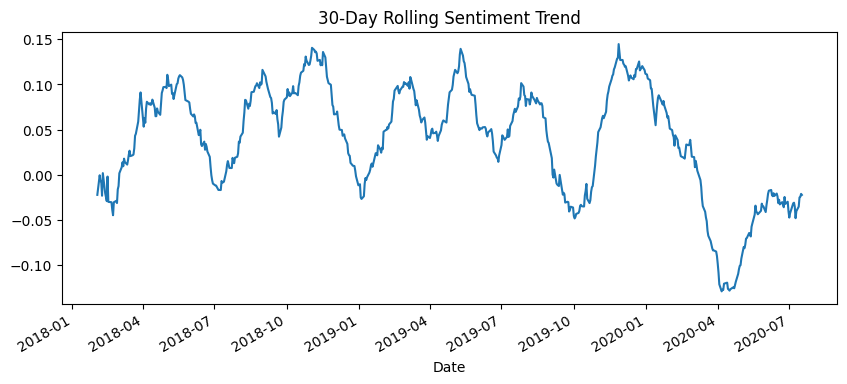

In [14]:
df['sentiment_rolling'] = df['daily_sentiment'].rolling(window=30).mean()

df['sentiment_rolling'].plot(figsize=(10,4))
plt.title("30-Day Rolling Sentiment Trend")
plt.show()


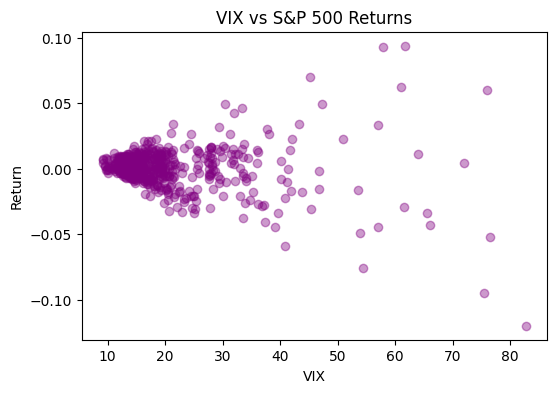

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(df['vix'], df['return'], alpha=0.4, color='purple')
plt.xlabel("VIX")
plt.ylabel("Return")
plt.title("VIX vs S&P 500 Returns")
plt.show()
